<a href="https://colab.research.google.com/github/JBorean11/EMSC2010-GroupW5-PP/blob/main/EMSC2010_PrecipitationPirates_W5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Group Project template

## 1. Project Overview
Group name: Precipitation Pirates

Project week:5

Project title: Earth's Ocean $CO_2$ Concentration

Datasets used (name and source): Global Ocean Data Analysis Project version 2.2023 (GLODAPv2.2023);NOAA National Centers for Environmental Information (NCEI)

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Notes |
| :--- | :--- | :--- | :--- | :--- |
| Github & integration | Juliet | Khai | `Yes`/Partial/ No| Inital Role complete, I will commit to GitHub as needed.|
| Data steward | Binyao | Kedi | `Yes`/Partial/ No| 	Integrated and cleaned ocean CO2 datasets from four major oceans (Pacific, Atlantic, Indian, Arctic). Created a unified global observation dataset.|
| Analysis / modelling | Lee | Juliet | `Yes`/Partial/ No| Add note|
| Visualisation / interpretation | Kedi | Binyao | `Yes`/Partial/ No| Add note|
| Narrative | Khai | Lee | `Yes`/Partial/ No| Efforts made to make the project flow from bootstrap resampling to plots of data. Brief explanations of what was being done in the code.|


## 3. Deputy Interventions (if applicable)
Repeat text as required.

* Role affected:

* Reason (e.g. missed deadline, absence, etc.):

* Deputy action taken:

* Impact on workflow:

*N.B., this section should be factual, not judgemental.*

## 4. Pre-submission checklist
* Notebook runs from top to bottom.
* Datafiles are included in the GitHub repository.
* Commits include meaningful information.
* Each group member has included a brief reflection in the notebook.
* Repository has been shared with the teaching team once your project is completed.

# Start your group project here

This project aims to investigate the $CO_2$ content of the Earth's oceans, and explore how dissolved $CO_2$ varies with depth.

$CO_2$ data from four major oceans (Pacific, Atlantic, Indian, and Arctic) has been exported and cleaned, ready to be analysed and modelled.

In [2]:
import pandas as pd
import numpy as np

In [3]:
import zipfile
import os

# Define the zip files for each ocean region
zip_files = {
    'Pacific': 'GLODAPv2.2023_Pacific_Ocean.zip',
    'Atlantic': 'GLODAPv2.2023_Atlantic_Ocean.zip',
    'Indian': 'GLODAPv2.2023_Indian_Ocean.zip',
    'Arctic': 'GLODAPv2.2023_Arctic_Ocean.zip'
}

# Extract each zip file into the current directory
for name, zip_name in zip_files.items():
    with zipfile.ZipFile(zip_name, 'r') as z:
        z.extractall('.')

In [4]:
# Map each ocean region to its corresponding CSV file
ocean_files = {
    'Pacific': 'GLODAPv2.2023_Pacific_Ocean.csv',
    'Atlantic': 'GLODAPv2.2023_Atlantic_Ocean.csv',
    'Indian': 'GLODAPv2.2023_Indian_Ocean.csv',
    'Arctic': 'GLODAPv2.2023_Arctic_Ocean.csv'
}

In [5]:
# Initialise empty list to store data from all oceans
all_ocean_data = []

for ocean_name, file_path in ocean_files.items():
    try:
        # Read CSV file into a dataframe
        df = pd.read_csv(file_path)
        # Replace missing value code -9999 with NaN
        df.replace(-9999, np.nan, inplace=True)
        # Keep only rows with valid CO2 measurements
        clean_df = df[df['G2tco2'].notna()].copy()
        # Add a column to identify the ocean region
        clean_df['Ocean_Region'] = ocean_name
        all_ocean_data.append(clean_df)
        print(f"Processed {ocean_name}: {len(clean_df)} rows.")
    except Exception as e:
        print(f"Error processing {ocean_name}: {e}")

Processed Pacific: 52351 rows.
Processed Atlantic: 193489 rows.
Processed Indian: 76390 rows.
Processed Arctic: 52351 rows.


In [6]:
# If data was successfully loaded, merge all ocean regions into one master dataframe
if all_ocean_data:
    global_df = pd.concat(all_ocean_data, ignore_index=True)

    # Select only the relevant columns for analysis
    cols = ['G2longitude', 'G2latitude', 'G2year', 'G2month', 'G2depth', 'G2tco2', 'Ocean_Region']
    final_data = global_df[cols]

    # Save the cleaned master dataset to a CSV file for use in subsequent analysis
    final_data.to_csv('global_surface_co2_master.csv', index=False)

    print(f"Total rows: {len(final_data)}")
    print(final_data.head())


Total rows: 374581
   G2longitude  G2latitude  G2year  G2month  G2depth  G2tco2 Ocean_Region
0       31.543      81.575  1987.0      7.0     15.0  2058.0      Pacific
1       31.543      81.575  1987.0      7.0     50.0  2092.0      Pacific
2       31.543      81.575  1987.0      7.0     69.0  2108.0      Pacific
3       31.543      81.575  1987.0      7.0     89.0  2111.0      Pacific
4       31.543      81.575  1987.0      7.0    148.0  2107.0      Pacific


The first step in this project is to conduct bootstrap resampling on our $CO_2$ data. This will produce a robust estimate on the global mean $CO_2$ concentration, also determining a 95% confidence interval. The resulting mean is 2160.63 micromol per kilogram and the 95% confidence interval between 2160.36 and 2160.90 micromols per kilogram.

In [7]:
file_name = "global_surface_co2_master.csv"

df = pd.read_csv(file_name)

In [8]:
# Extract CO2 values
co2_data = df["G2tco2"].values

In [9]:
X = co2_data

n = len(X)
num_samples = 10000

means = np.empty(num_samples)

# Perform bootstrap resampling
for i in range(num_samples):
    sample = np.random.choice(X, size=n, replace=True)  # resample data
    means[i] = np.mean(sample)  # compute mean for this sample

# Confidence interval
CI = np.percentile(means, [2.5, 97.5])

print("Mean estimate:", np.mean(means))
print("95% CI:", CI)

Mean estimate: 2160.6302996894897
95% CI: [2160.362776  2160.8961103]


The results from the above bootstrap resampling (mean estimate and 95% confidence interval) are visualised in the plot below.

### Extending Bootstrap Analysis: Comparing Mean CO2 Between Ocean Regions

To further demonstrate bootstrapping, it can be used to compare the mean CO2 concentrations between two different ocean regions. it will calculate a bootstrap confidence interval for the difference in the mean co2 levels between the Pacific and Atlantic Oceans. This allows an assessment if there is a significant difference between these two regions.

In [10]:
pacific_co2 = df[df['Ocean_Region'] == 'Pacific']['G2tco2'].values
atlantic_co2 = df[df['Ocean_Region'] == 'Atlantic']['G2tco2'].values

n_pacific = len(pacific_co2)
n_atlantic = len(atlantic_co2)
num_samples = 10000

difference_in_means = np.empty(num_samples)

for i in range(num_samples):
    # Resample Pacific data and calculate mean
    sample_pacific = np.random.choice(pacific_co2, size=n_pacific, replace=True)
    mean_pacific = np.mean(sample_pacific)

    # Resample Atlantic data and calculate mean
    sample_atlantic = np.random.choice(atlantic_co2, size=n_atlantic, replace=True)
    mean_atlantic = np.mean(sample_atlantic)

    # Calculate the difference in means
    difference_in_means[i] = mean_pacific - mean_atlantic

# Calculate the 95% confidence interval for the difference in means
ci_difference = np.percentile(difference_in_means, [2.5, 97.5])

print(f"Mean difference (Pacific - Atlantic): {np.mean(difference_in_means):.2f} µmol/kg")
print(f"95% CI for the difference: [{ci_difference[0]:.2f}, {ci_difference[1]:.2f}] µmol/kg")

Mean difference (Pacific - Atlantic): -38.81 µmol/kg
95% CI for the difference: [-39.60, -38.00] µmol/kg


The confidence interval for the difference in means can tell us if there's a statistically significant difference between the two groups. If the interval does not contain zero, it suggests that the difference is statistically significant at the 95% confidence level.

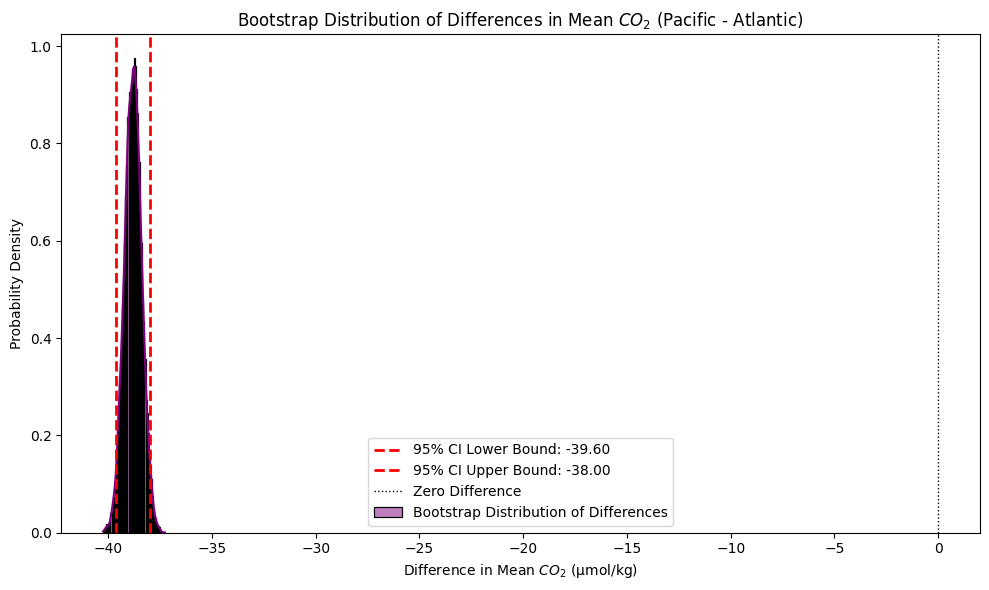

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 6))
sns.histplot(difference_in_means, kde=True, color='purple', stat="density", label='Bootstrap Distribution of Differences')

plt.axvline(ci_difference[0], color='red', linestyle='--', linewidth=2, label=f'95% CI Lower Bound: {ci_difference[0]:.2f}')
plt.axvline(ci_difference[1], color='red', linestyle='--', linewidth=2, label=f'95% CI Upper Bound: {ci_difference[1]:.2f}')
plt.axvline(0, color='black', linestyle=':', linewidth=1, label='Zero Difference')

plt.title('Bootstrap Distribution of Differences in Mean $CO_2$ (Pacific - Atlantic)')
plt.xlabel('Difference in Mean $CO_2$ (µmol/kg)')
plt.ylabel('Probability Density')
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_16030/3048175908.py:31: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Total Dissolved Inorganic Carbon ($G2tco2$, $\mu$mol/kg)')


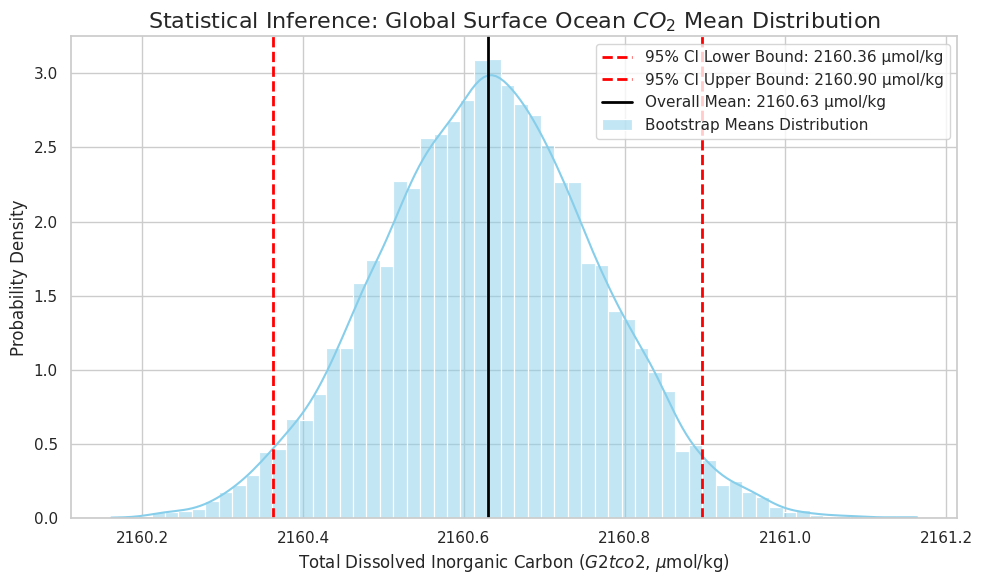

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set professional plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['font.family'] = 'sans-serif'

# ---------------------------------------------------------
# Block 1: Bootstrap Distribution of Means
# (Requires 'means' and 'CI' from the Modelling step)
# ---------------------------------------------------------

plt.figure()

# 1. Plot histogram of the 10,000 bootstrap means with Kernel Density Estimate (KDE)
sns.histplot(means, kde=True, color='skyblue', stat="density", label='Bootstrap Means Distribution')

# 2. Annotate the 95% Confidence Interval (CI) with vertical dashed lines
plt.axvline(CI[0], color='red', linestyle='--', linewidth=2, label=f'95% CI Lower Bound: {CI[0]:.2f} µmol/kg')
plt.axvline(CI[1], color='red', linestyle='--', linewidth=2, label=f'95% CI Upper Bound: {CI[1]:.2f} µmol/kg')

# 3. Annotate the overall mean of the bootstrap distribution
bootstrap_mean = np.mean(means)
plt.axvline(bootstrap_mean, color='black', linestyle='-', linewidth=2, label=f'Overall Mean: {bootstrap_mean:.2f} µmol/kg')

# 4. Figure aesthetics and labeling
plt.title('Statistical Inference: Global Surface Ocean $CO_2$ Mean Distribution')
plt.xlabel('Total Dissolved Inorganic Carbon ($G2tco2$, $\mu$mol/kg)')
plt.ylabel('Probability Density')
plt.legend(frameon=True, loc='upper right')
plt.tight_layout()

plt.show()

The extremely narrow confidence interval shows that our estimation has high precision. This proves that even if there are fluctuations in ocean data, the global benchmark value we obtain through large-scale data consolidation is extremely robust and can be used as a reliable reference point for subsequent climate change research.



Using the cleaned data of four major oceans, box plots have been created to visualise how $CO_2$ concentration varies across different environments. These plots can be found below.

<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_16030/3695385021.py:18: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Total Dissolved Inorganic Carbon ($G2tco2$, $\mu$mol/kg)')
/tmp/ipykernel_16030/3695385021.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Ocean_Region', y='G2tco2', data=df, palette="Set2", showfliers=False)


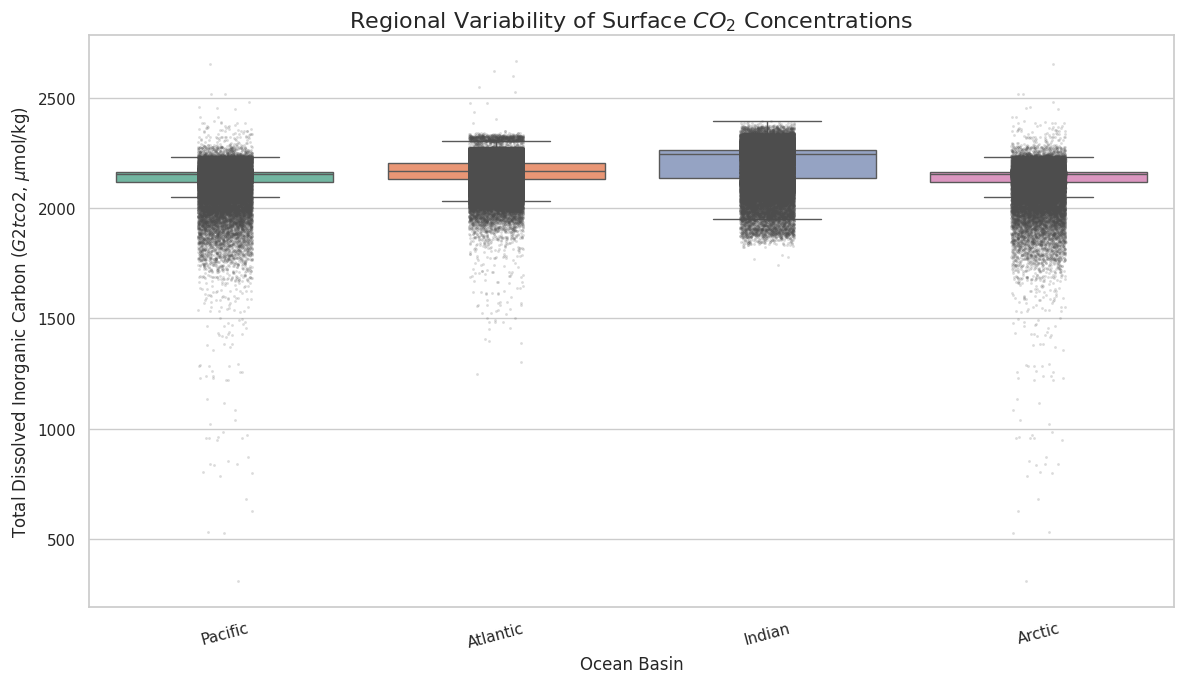

In [13]:
# ---------------------------------------------------------
# Block 2: Regional Comparison via Boxplot
# (Requires the 'df' or 'final_data' DataFrame)
# ---------------------------------------------------------

if 'df' in locals():
    plt.figure(figsize=(12, 7))

    # Create a boxplot to compare CO2 levels across regions
    # showfliers=False hides outliers to focus on the interquartile range
    sns.boxplot(x='Ocean_Region', y='G2tco2', data=df, palette="Set2", showfliers=False)

    # Overlay a stripplot to show data density and distribution
    sns.stripplot(x='Ocean_Region', y='G2tco2', data=df, color=".3", size=2, alpha=0.2)

    plt.title('Regional Variability of Surface $CO_2$ Concentrations')
    plt.xlabel('Ocean Basin')
    plt.ylabel('Total Dissolved Inorganic Carbon ($G2tco2$, $\mu$mol/kg)')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame 'df' not found. Please ensure data was loaded correctly.")

Analysing the plots, we can note the temperature effect. High latitudes (such as the Arctic Ocean) usually have a higher $CO_2$ solubility than low latitudes, due to the fact cold water can disolve more gases. The difference in the height of the box reflects the unique cyclic patterns of each ocean (such as the formation of deep water in the North Atlantic) and the differences in biological productivity. Those lower discrete points may represent specific observed moments when biophotosynthesis is extremely active and consumes a lot of surface carbon.

Lastly, a scatter plot has been generated to show how dissolved $CO_2$ varies with ocean depth.

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_16030/2942879139.py:16: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Total Dissolved Inorganic Carbon ($G2tco2$, $\mu$mol/kg)')


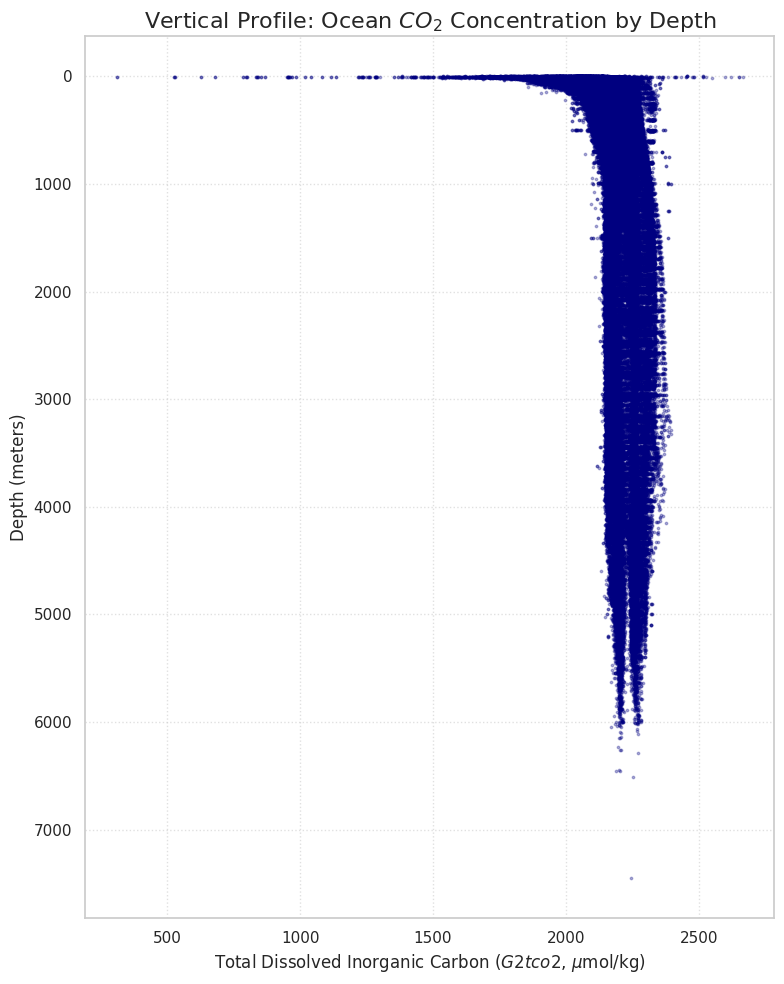

In [14]:
# ---------------------------------------------------------
# Block 3: Vertical Concentration Profile (Depth vs CO2)
# (Requires 'G2depth' and 'G2tco2' columns)
# ---------------------------------------------------------

if 'df' in locals():
    plt.figure(figsize=(8, 10))

    # Scatter plot for Depth vs CO2
    plt.scatter(df['G2tco2'], df['G2depth'], s=3, color='navy', alpha=0.3)

    # CRITICAL: Invert Y-axis so 0m (Surface) is at the top
    plt.gca().invert_yaxis()

    plt.title('Vertical Profile: Ocean $CO_2$ Concentration by Depth')
    plt.xlabel('Total Dissolved Inorganic Carbon ($G2tco2$, $\mu$mol/kg)')
    plt.ylabel('Depth (meters)')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

Analysing the plot, we note observations and causations at the surface layer, and the deep ocean.

Surface Layer (0-500m): Low and highly variable $CO_2$ concentrations. This is caused by photosynthesis (phytoplankton consuming carbon to grow).

Deep Ocean (below 1000m): High and stable concentrations. This reflects the Biological Pump: as organic matter sinks and decomposes, carbon is released and "stored" in the deep ocean.

The ocean acts as a massive carbon sink, transporting atmospheric $CO_2$ from the surface to the deep sea.

# Group reflections
1. **Juliet:** I was able to create the Github and Colab without too much problem, however insteaded of sharing the Colab link with the group I only provided the one to the repository. This meant that no one was able to save their edits on the Colab, which was a problem only solved close to the end of the project. So I ended up transferring code from others Colabs in order to maintain a central document.

2. **Binyao:** In this project, my role was to upload and manage the ocean dataset files to GitHub and Colab. I encountered difficulties when attempting to upload the CSV files, as the file sizes exceeded GitHub’s upload limit. To address this, I compressed the files into zip format and used GitHub Desktop to successfully push them to the repository. I also learned how to modify the Colab code to extract and read the compressed files correctly. This process taught me the importance of file management and how to troubleshoot data pipeline issues when working with large datasets.
3. **Lee:** In this project, i was able to implement a bootstrap resampling method to estimate the global mean ocean CO2 concentration. During this process i encountered issues when attempting to generate a large number of bootstrap samples in colab, as colab would crash due to exceeding the available ram. To address this, i adjusted the implementation to use a more memory efficient approach. I learned how to adapt algorithims to meet memory constraints when working with a large dataset.
4. **Kedi:**
5. **Khai:** Even though my role wasn't involved in writing or generating code, I found it was still important to understand what each line of code was doing in order to generate a flow for the project. This was a bit tricky and took a bit of time, but was worthwhile as it made my task more starightforward.